# Importando pacotes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Lendo banco de dados com o pacote Pandas

In [ ]:
df = pd.read_excel('chuvas_marilia.xlsx')
df

,mes_ano,dias_chuva
0,2021-01-01,18
1,2021-02-01,8
2,2021-03-01,13
3,2021-04-01,2
4,2021-05-01,3
5,2021-06-01,6
6,2021-07-01,2
7,2021-08-01,2
8,2021-09-01,5
9,2021-10-01,16


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   mes_ano     24 non-null     datetime64[ns]
 1   dias_chuva  24 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 516.0 bytes


In [ ]:
df["Ano"] = df["mes_ano"].dt.year

In [ ]:
dias_2021 = df[df["Ano"] == 2021]["dias_chuva"]
dias_2022 = df[df["Ano"] == 2022]["dias_chuva"]

# Descrição Tabular
- distribuição de frequência


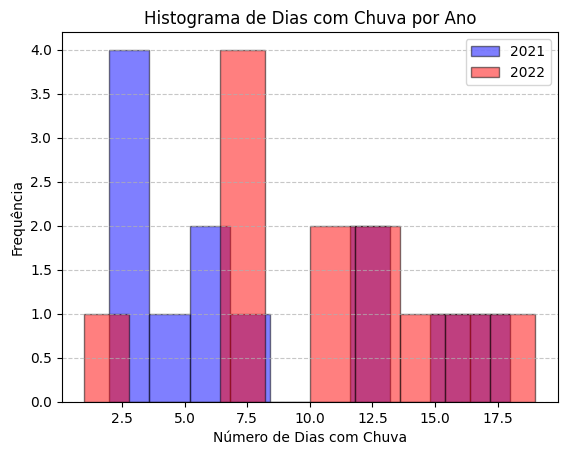

In [ ]:
fig, ax = plt.subplots()
plt.hist(dias_2021, bins=10, alpha=0.5, color='blue', label="2021", edgecolor='black')
plt.hist(dias_2022, bins=10, alpha=0.5, color='red', label="2022", edgecolor='black')

# Ajustes no gráfico
plt.xlabel("Número de Dias com Chuva")
plt.ylabel("Frequência")
plt.title("Histograma de Dias com Chuva por Ano")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir o gráfico
plt.show()

## Boxplot

C:\Users\Lucas\AppData\Local\Temp\ipykernel_19268\3827282478.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dias_2021, dias_2022], labels=["2021", "2022"], patch_artist=True, boxprops=dict(facecolor="lightblue"))


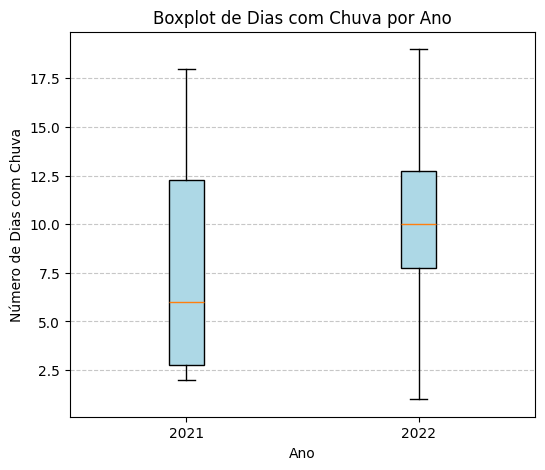

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot([dias_2021, dias_2022], labels=["2021", "2022"], patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.xlabel("Ano")
plt.ylabel("Número de Dias com Chuva")
plt.title("Boxplot de Dias com Chuva por Ano")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Descrição Gráfica

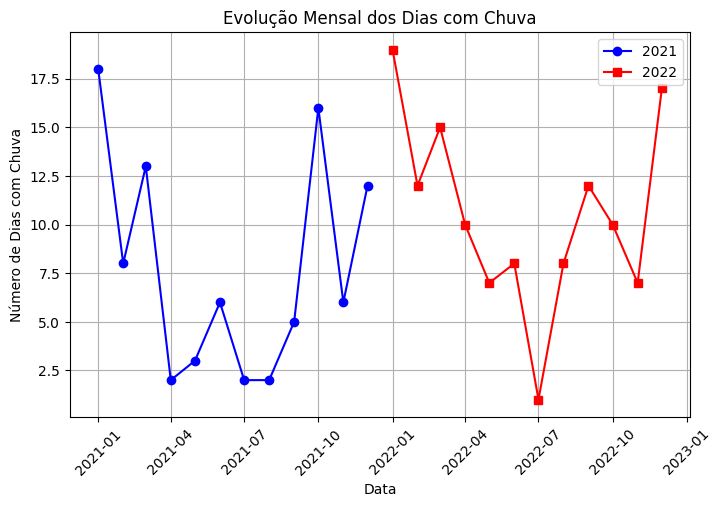

In [ ]:
plt.figure(figsize=(8, 5))

# Plotando os dados para cada ano
plt.plot(df[df["Ano"] == 2021]["mes_ano"], df[df["Ano"] == 2021]["dias_chuva"], marker='o', linestyle='-', color='blue', label="2021")

plt.plot(df[df["Ano"] == 2022]["mes_ano"], df[df["Ano"] == 2022]["dias_chuva"], marker='s', linestyle='-', color='red', label="2022")

# Ajustes no gráfico
plt.xlabel("Data")
plt.ylabel("Número de Dias com Chuva")
plt.title("Evolução Mensal dos Dias com Chuva")
plt.xticks(rotation=45)  # Rotacionar os rótulos para melhor visualização
plt.legend()
plt.grid(True)

# Exibir o gráfico
plt.show()


# Descrição Paramétrica

In [ ]:
# Calculando medidas de posição, dispersão e intervalo de confiança
def estatisticas(dados):
    media = np.mean(dados)
    mediana = np.median(dados)
    moda = stats.mode(dados, keepdims=True)[0][0]
    variancia = np.var(dados, ddof=1)  # ddof=1 para amostra
    desvio_padrao = np.std(dados, ddof=1)
    coef_var = (desvio_padrao / media) * 100  # CV em porcentagem

    # Intervalo de Confiança 95%
    n = len(dados)
    erro_padrao = desvio_padrao / np.sqrt(n)
    t_critico = stats.t.ppf(0.975, df=n-1)  # t-student para 95%
    margem_erro = t_critico * erro_padrao
    intervalo = (media - margem_erro, media + margem_erro)

    return {
        "Média": media,
        "Mediana": mediana,
        "Moda": moda,
        "Variância": variancia,
        "Desvio Padrão": desvio_padrao,
        "Coef. de Variação (%)": coef_var,
        "IC 95%": intervalo
    }


estat_2021 = estatisticas(dias_2021)
estat_2022 = estatisticas(dias_2022)

# Resultados
df_estatisticas = pd.DataFrame([estat_2021, estat_2022], index=["2021", "2022"])
print(df_estatisticas)


      Média  Mediana  Moda  Variância  Desvio Padrão  Coef. de Variação (%)  \
2021   7.75      6.0     2  32.204545       5.674905              73.224579   
2022  10.50     10.0     7  24.272727       4.926736              46.921295   

                                       IC 95%  
2021   (4.14433745755876, 11.355662542441241)  
2022  (7.369701310118033, 13.630298689881968)  


# Segundo banco de Dados
- Quantitativos contínuos

In [ ]:
df2 = pd.read_excel('vazao_marilia.xlsx')
df2

,data,vazao
0,2021-01-01,3.017
1,2021-01-02,2.876
2,2021-01-03,2.876
3,2021-01-04,2.806
4,2021-01-05,2.841
...,...,...
725,2022-12-27,3.534
726,2022-12-28,3.487
727,2022-12-29,NaN
728,2022-12-30,NaN


In [ ]:
print(df2.isnull().sum())
# verificando valores nulos

data      0
vazao    10
dtype: int64


- mostrando as datas correspondentes a esses valores

In [ ]:
print(df2[df2.isnull().any(axis=1)])

          data  vazao
242 2021-08-31    NaN
303 2021-10-31    NaN
362 2021-12-29    NaN
363 2021-12-30    NaN
364 2021-12-31    NaN
607 2022-08-31    NaN
668 2022-10-31    NaN
727 2022-12-29    NaN
728 2022-12-30    NaN
729 2022-12-31    NaN


In [ ]:
df2.fillna(0, inplace=True)
print(df2.isnull().sum())  # Retornar 0 para todas as colunas


data     0
vazao    0
dtype: int64


In [ ]:
def print_full(df): # função para ver todo o banco de dados. Thanks stacke overflow!!
    import pandas as pd
    pd.set_option('display.max_rows', len(df))
    print(df)
    pd.reset_option('display.max_rows')

In [ ]:
print_full(df2)

          data   vazao
0   2021-01-01   3.017
1   2021-01-02   2.876
2   2021-01-03   2.876
3   2021-01-04   2.806
4   2021-01-05   2.841
5   2021-01-06   2.702
6   2021-01-07   2.667
7   2021-01-08   2.667
8   2021-01-09   2.771
9   2021-01-10   2.702
10  2021-01-11   2.667
11  2021-01-12   2.667
12  2021-01-13   2.632
13  2021-01-14   2.598
14  2021-01-15   2.598
15  2021-01-16   2.632
16  2021-01-17   2.632
17  2021-01-18   2.667
18  2021-01-19   2.598
19  2021-01-20   2.632
20  2021-01-21   2.667
21  2021-01-22   2.667
22  2021-01-23   2.667
23  2021-01-24   2.667
24  2021-01-25   2.736
25  2021-01-26   2.702
26  2021-01-27   2.667
27  2021-01-28   2.598
28  2021-01-29   2.564
29  2021-01-30   2.632
30  2021-01-31   2.598
31  2021-02-01   2.598
32  2021-02-02   2.667
33  2021-02-03   2.736
34  2021-02-04   2.667
35  2021-02-05   2.736
36  2021-02-06   2.702
37  2021-02-07   2.667
38  2021-02-08   2.702
39  2021-02-09   2.598
40  2021-02-10   2.632
41  2021-02-11   2.736
42  2021-02

In [ ]:
df2['Ano']= df2['data'].dt.year
vazao_2021 = df2[df2['Ano'] == 2021]['vazao']
vazao_2022 = df2[df2['Ano'] == 2022]['vazao']

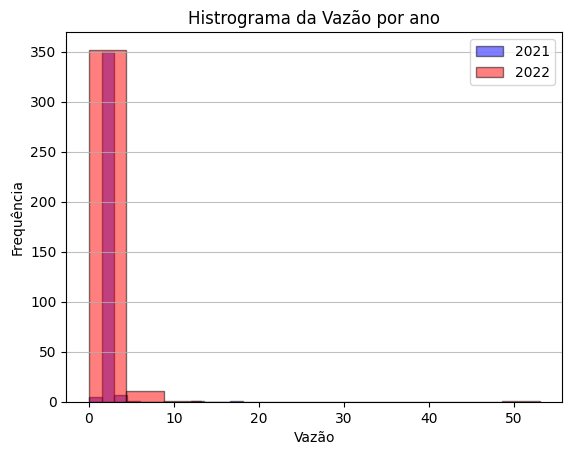

In [ ]:
fig, ax = plt.subplots()
plt.hist(vazao_2021, bins=12, alpha=0.5, color='blue', label='2021', edgecolor='black')
plt.hist(vazao_2022, bins=12, alpha=0.5, color='red', label='2022', edgecolor='black')

plt.xlabel('Vazão')
plt.ylabel('Frequência')
plt.title('Histrograma da Vazão por ano')
plt.legend()
plt.grid(axis='y', linestyle='-', alpha=0.8)
plt.show()

## Boxplot

C:\Users\Lucas\AppData\Local\Temp\ipykernel_19268\2944136311.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([vazao_2021, vazao_2022], labels=['2021', '2022'], patch_artist=True, boxprops=dict(facecolor='blue'))


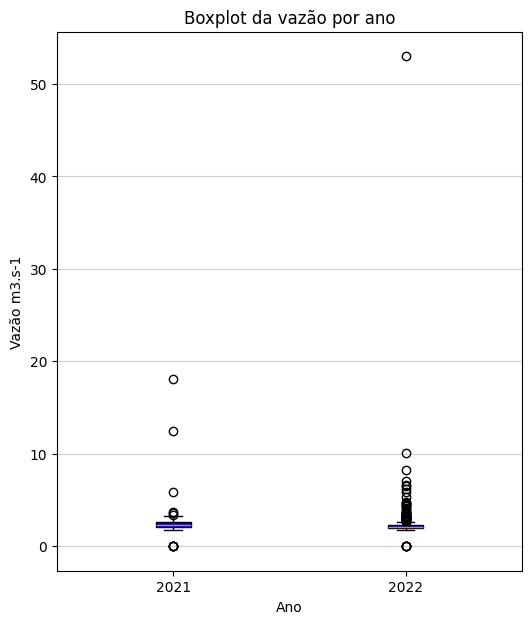

In [ ]:
plt.figure(figsize=(6,7))
plt.boxplot([vazao_2021, vazao_2022], labels=['2021', '2022'], patch_artist=True, boxprops=dict(facecolor='blue'))
plt.xlabel('Ano')
plt.ylabel('Vazão m3.s-1')
plt.title('Boxplot da vazão por ano')
plt.grid(axis='y', linestyle='-', alpha=0.6)
plt.show()

# Descrição Gráfica

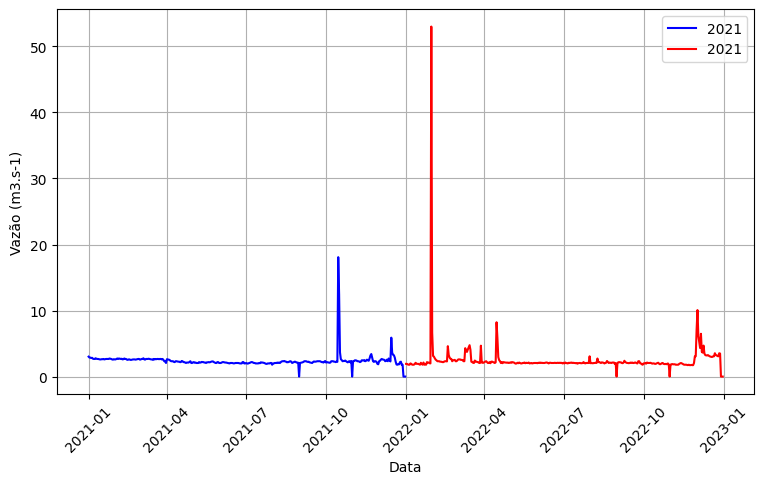

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(df2[df2['Ano'] ==2021]['data'], df2[df2['Ano']==2021]['vazao'], linestyle='-', color='blue', label='2021')
plt.plot(df2[df2['Ano'] ==2022]['data'], df2[df2['Ano']==2022]['vazao'], linestyle='-', color='red', label='2021')
plt.xlabel("Data")
plt.ylabel("Vazão (m3.s-1)")
plt.xticks(rotation=45)  # Rotacionar os rótulos para melhor visualização
plt.legend()
plt.grid(True)
plt.show()

# Descrição Paramétrica

In [ ]:
# rodando a função já criada
estat1_2021 = estatisticas(vazao_2021)
estat2_2022 = estatisticas(vazao_2022)

# Exibindo os resultados
df_estatisticas = pd.DataFrame([estat1_2021, estat2_2022], index=["2021", "2022"])
print(df_estatisticas)

         Média  Mediana   Moda  Variância  Desvio Padrão  \
2021  2.381622    2.258  2.058   1.152306       1.073455   
2022  2.454441    2.058  2.058   7.900560       2.810794   

      Coef. de Variação (%)                                    IC 95%  
2021              45.072444   (2.271129618068816, 2.4921142175476216)  
2022             114.518679  (2.1651220458589915, 2.7437601459218293)  


# 2. Exercício
- Para 10 artigos da sua área de atuação, pede-se:

a. Objetivo do trabalho.

b. Métodos Estatísticos aplicado a análise de dados.

c. Delineamento, se houver.

d. Tratamento, se houver.

e Variáveis respostas, classifique-as.

f. Outras informações relevantes.

## Artigo 1
- https://doi.org/10.1016/j.ejrh.2025.102604


### A)


- objetivo:
(1) analisar sistematicamente as diferenças no desempenho da simulação e suas causas em simulações de escoamento anual, mensal e diário sob duas abordagens de desenvolvimento de modelo SWAT comumente usadas e (2) investigar os padrões de variações de parâmetros sensíveis em diferentes escalas de tempo e explorar suas implicações a partir das perspectivas do significado físico dos parâmetros e mecanismos hidrológicos. Os


### B)
- As métricas estatísticas abaixo foram utilizadas para avaliar os modelos deste artigo:

$$
KGE = 1 - \sqrt{(r - 1)^2 + (\beta - 1)^2 + (\gamma - 1)^2}
$$
$$
PBIAS = 100 \times \frac{\sum_{i=1}^{n} (Q_{o,i} - Q_{s,i})}{\sum_{i=1}^{n} Q_{o,i}}
$$
$$
NS = 1 - \frac{\sum_{i=1}^{n} (Q_{o,i} - Q_{s,i})^2}{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)^2}
$$
$$
R^2 = \left( \frac{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)(Q_{s,i} - \bar{Q}_s)}{\sqrt{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)^2} \sqrt{\sum_{i=1}^{n} (Q_{s,i} - \bar{Q}_s)^2}} \right)^2
$$
Com:

$r$: correlação de Pearson entre observado e simulado;

$\beta = \dfrac{\bar{Q}_s}{\bar{Q}_o}$: razão entre médias;

$\gamma = \dfrac{CV_s}{CV_o}$: razão dos coeficientes de variação;

$Q_{o,i}$: valor observado no tempo $i$;

$Q_{s,i}$: valor simulado no tempo $i$

### C)
- não houve delineamento estatístico

### D)
- não houve tratamento estatístico

### E)
- Neste estudo a variável resposta era a __vazão__ das duas bacias hidrográficas, em três escalas de tempo: vazão diária, mensal e anual. Em que, essa variável é __quantitativa contínua__.

### F)
- Neste estudo, os autores calibraram e validaram 16 parâmetros importantes na simulação do modelo SWAT para a vazão de bacias hidrográficas, como: __CN2__ (Curva-Número na condição de umidade II
(adimensional)), __SURLAG__ (Coeficiente de retardamento do escoamento superficial (adimensional)), __ALPHA_BF__(Fator de recessão de fluxo de base (dias) ), __ESCO__ (Fator de compensação da evaporação de água do solo (adimensional)) e __SOL_AWC__ (Capacidade de água disponível no solo (mm H2O/mm
solo)).

---
## Artigo 2
- https://doi.org/10.1016/j.jenvman.2025.126053

### A)


- Objetivo:
Foi realizar uma análise comparativa entre o modelo SWAT autônomo e o modelo híbrido SWAT-XGBoost para verificar o valor agregado na precisão preditiva e na confiabilidade da simulação das abordagens de modelagem de acoplamento.

### B)
- Neste artigo foram utilizadas duas métricas estatísticas para avaliar a precisão dos modelos hidrológicos:
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (Q_{o,i} - Q_{s,i})^2 }
$$

$$
R^2 = \left( \frac{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)(Q_{s,i} - \bar{Q}_s)}{\sqrt{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)^2} \sqrt{\sum_{i=1}^{n} (Q_{s,i} - \bar{Q}_s)^2}} \right)^2
$$

 Onde:

$n$: número de observações;

$Q_{o,i}$: valor observado no tempo $i$;

$Q_{s,i}$: valor simulado ou previsto no tempo $i$.


### C)
- Não houve delianeamento estatístico

### D)
- Não houve tratamento estatístico

### E)
- Neste estudo, foi feita uma comparação do modelo SWAT com o XGBoost, optimizando para a predição de NO3-N e PO4-, concentrações de P em uma bacia hidrográfica agrícola. Essas variáveis são __variáveis quantitativas contínuas__ no modelo SWAT.

### F)
- Apesar do uso de um algoritmo de aprendizado de máquina (XGBoost) ter melhorado significativamente a precisão da previsão em comparação com o modelo SWAT, os autores fazem alguns apontamentos importantes acerca das limitações. E se trata do potencial de sobreajuste com o modelo XGBoost no treinamento, se o conjunto de dados não for muito extenso ou representativo de várias condições, especialmente na presença de alta dimensão derivadas de saídas do SWAT. Esse sobreajuste pode diminuir a capacidade do modelo generalizar, induzindo ele a produzir previsões imprecisas quando testadas em dados novos ou desconhecidos. Outra limitação importante apontada, é a integração de um modelo transparente e bem consolidado baseado em física, que é o modelo SWAT, com um algoritmo de caixa preta, como o XGBoost. E como a abordagem do modelo SWAT permite uma interpretação clara dos processos hidrológicos e de nutrientes, os modelos XGBoost são frequentemente criticados por sua falta de interpretabilidade, o que dificulta uma comunicação eficiente às partes interessadas e tomadores de decisão.

---
## Artigo 3
- https://doi.org/10.1016/j.rineng.2025.105905


### A)
- Objetivo: Simular a vazão mensal com o modelo SWAT para o período histórico de 1981 a 2020.

### B)
- Neste artigo foram utilizadas quatro métricas estatísticas para avaliar a precisão dos modelos hidrológicos:
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (Q_{o,i} - Q_{s,i})^2 }
$$
$$
PBIAS = 100 \times \frac{\sum_{i=1}^{n} (Q_{o,i} - Q_{s,i})}{\sum_{i=1}^{n} Q_{o,i}}
$$
$$
NSE = 1 - \frac{\sum_{i=1}^{n} (Q_{o,i} - Q_{s,i})^2}{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)^2}
$$
$$
R^2 = \left( \frac{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)(Q_{s,i} - \bar{Q}_s)}{\sqrt{\sum_{i=1}^{n} (Q_{o,i} - \bar{Q}_o)^2} \sqrt{\sum_{i=1}^{n} (Q_{s,i} - \bar{Q}_s)^2}} \right)^2
$$
Com:

$r$: correlação de Pearson entre observado e simulado;

$\beta = \dfrac{\bar{Q}_s}{\bar{Q}_o}$: razão entre médias;

$\gamma = \dfrac{CV_s}{CV_o}$: razão dos coeficientes de variação;

$Q_{o,i}$: valor observado no tempo $i$;

$Q_{s,i}$: valor simulado no tempo $i$

### C)
- Não houve delianeamento estatístico

### D)
- Não houve tratamento estatístico

### E)
- Neste estudo a variável resposta era a __vazão__ em uma bacia hidrográfica, essa variável é __quantitativa contínua__.

### F)
- Os autores recomendam fortemente o uso de mapas que captem as mudanças do uso e cobertura do solo para cenários de estudos futuros, combinando com as mudanças climáticas nos processos hidrológicos.

---
## Artigo 4
- https://doi.org/10.5039/agraria.v3i3a264


### A)
- Objetivo:  Avaliar  o comportamento de dois híbridos de melão com relação a tolerância à salinidade, sob  diferentes frequências  de irrigação.

### B)
- Neste estudo foi realizado análises das características físicas do solo, nas profundidades: 0-15, 15-30 e 30-45 cm. Além de análise da água utilizada na irrigação, como a condutividade elétrica (CE), Relação de adsorção de sódio (RAS) e pH, dentre outros.

### C)
- O delineamento utilizado foi fatorial triplo casualizado.

### D)
- O primeiro tratamento foi a salinidade da água da irrigação, em três níveis;
- O segundo tratamento foi duas cultivares de melão;
O terceiro tratamento foi a frequência da irrigação.

### E)
- A variável resposta neste estudo foi a produção (rendimento total e peso médio dos frutos). Ambas sendo variáveis quantitativas contínuas.

### F)
- Após a análise de variância  foi realizado a regressão, comparando os fatores quantitativos com 5% de significância.

---
## Artigo 5
- https://doi.org/10.1590/S1415-43662013000700007


### A)
- Objetivo:  Quantificar o desempenho de três formas de manejo da irrigação, tensiometria, tanque Classe A e Penman Monteith, do feijoeiro cultivado no sistema de integração
lavoura-pecuária, em Santo Antônio de Goiás, Goiás.

### B)
- Neste trabalho os tratamentos foram submetidos ao teste F.

### C)
-  O delineamento experimental empregado foi o inteiramente casualizado com nove parcelas de cada tratamento dispostas aleatoriamente em faixas demarcadas a partir do centro do pivô.

### D)
- Foram utilizados três tratamentos no manejo da irrigação: Tensiometro, Tanque classe A e Penman-Monteith.

### E)
- A variável resposta neste estudo foi a produtividade sendo essa variável quantitativa contínua.

### F)
- O feijoeiro em plantio direto no sistema integração lavoura-pecuária apresenta maior produtividade de grãos quando a irrigação é manejada pelo método do tanque Classe A.

---
## Artigo 6
- https://doi.org/10.15809/irriga.2003v8n1p1-9

### A)
- Objetivo: Avaliar  o efeito de diferentes manejos da irrigação através da aplicação de  lâminas  críticas  determinadas  a partir  da  evapotranspiração  máxima  da  cultura, sobre    o    rendimento    e componentes    do rendimento  de  grãos  do  feijoeiro,  bem  como identificar   a   lâmina   mais   indicada   para   o manejo  da  irrigação  da  cultivar  BR-FEPAGRO 44.

### B)
- Foi utilizado a análise de variância nos resultados com 5% de significância.

### C)
- Utilizou-se   delineamento   experimental inteiramente casualizado com cinco repetições.

### D)
- Foram realizados na cultivar de feijão preto, quatro manejos de irrigação. Os tratamentos constaram de aplicação de irrigações  para elevar o conteúdo de água no solo ao limite superior de disponibilidade de água às plantas,  quando  a  evapotranspiração  máxima  da  cultura  estimada  pelo  método  do tanque  Classe  A, indicava   lâminas  acumuladas   de   15,   30,   45   e   60 mm.

### E)
- A variável resposta neste estudo foi o rendimento de grãos do feijoeiro, sendo uma variável quantitativa contínua.

### F)
- Para a cultivar de feijoeiro BR-FEPAGRO 44, o máximo rendimento de  grãos  é alcançado manejando a irrigação com aplicação de lâmina crítica de 30 a 35 mm.

---
## Artigo 7
- https://doi.org/10.1590/S0102-05362011000200018

### A)
- Objetivo:  Estudar o desenvolvimento de duas cultivares da alface (AF 1743 e OGR 326), em ambiente protegido.

### B)
-  A análise estatística dos resultados
foi realizada por meio da análise de variância dos dados (teste de F) e da com
paração de médias de tratamentos entre
si (teste de Tukey, 5% de probabilidade).

### C)
-  O delineamento estatístico utili
zado foi o inteiramente casualizado,
em esquema de parcelas subdivididas,
com dez repetições por tratamento,
constituídos  de dois manejos de irri
gação (M1 e M2) nas parcelas e duas
cultivares de alface (AF 1743 e OGR
326) nas subparcelas.

### D)
- Os manejos de irrigação: reposição de
água de irrigação determinada por tensiometria (M1) e reposição de
água determinada na evaporação de água de tanque reduzido (M2),
instalados em ambiente protegido.

### E)
- A variável resposta neste trabalho era o manejo adequado, sendo esse tipo de variável uma variável qualitativa.

### F)
- Os autores concluiram que, nas condições
experimentais avaliadas, o manejo de água por tensiometria promoveu melhor desempenho para as variáveis analisadas e maior eficiência no uso da água. Acultivar OGR 326, apresentou comportamento superior para a produção de massa fresca de parte aérea.

---
## Artigo 8
- https://doi.org/10.1590/S0103-90161997000100005


### A)
- Objetivo:  Avaliar o comportamento produtivo da alface, variedade "Mesa 659" (tipo americana), cultivada em uma estufa plástica e irrigada por gotejamento.

### B)
- Os resultados foram submetidos a análise de variância e posteriormente a regressão.

### C)
-  delineamento experimental de blocos ao acaso, com quatro tratamentos e cinco repetições, em um total de vinte parcelas.

### D)
- Os tratamentos analisados foram os seguintes: T25 - nível de irrigação correspondente a 25% da evaporação do Tanque Classe A; T50 - nível de irrigação correspondente a 50% da evaporação do Tanque Classe A; T75 - nível de irrigação correspondente a 75% da evaporação do Tanque Classe A e T100 - nível de irrigação correspondente a 100% da evaporação do Tanque Classe A.

### E)
- Foram avaliadas a matéria fresca por planta (MFP), a produtividade (PROD) e a eficiência do uso de água (EUA). Todas variáveis quantitativas contínuas.

### F)
- A aplicação de uma lâmina de irrigação equivalente a 75% da ECA (0,75 ECA) proporcionou a obtenção dos melhores resultados de matéria fresca por planta e produtividade da cultura.

---
## Artigo 9
- https://doi.org/10.1590/S0100-69162010000500011


### A)
- Objetivo: Estudar técnica e economicamente o efeito da irrigação por gotejamento na produção do cafeeiro (Coffea arabica L.)

### B)
- Neste trabalho foram efetuadas as análises de regressão, a fim de verificar a correlação entre a variável dependente (produtividade) e a variável independente (lâmina de irrigação).

### C)
- O delineamento experimental utilizado foi o de blocos casualizados, com cinco tratamentos e quatro repetições

### D)
- Os tratamentos foram: L0 = sem irrigação; L40 = 40%; L60 = 60%; L80 = 80% e L100 = 100% da Evaporação do Tanque Classe A (ECA).

### E)
- A variável resposta foi a produtividade, uma variável quantitativa contínua.

### F)
- Os autores concluiram que em áreas irrigadas, uma produtividade média de 67,19 sacas de café, em seis safras consecutivas, é suficiente para se atingir o ponto de nivelamento, ou seja, os custos totais da
atividade são iguais à receita total.

---
## Artigo 10
- https://doi.org/10.15809/irriga.2014v19n3p488

### A)
- Objetivo:  Verificar  a  maturação  e  a  classificação  do  café  grão  cru  em lavoura irrigada por gotejamento sob diferentes manejos em três safras após a poda

### B)
- A  análise  estatística  foi  realizada para verificar a normalidade de resíduos, pelo teste de Shapiro-Wilk, e de homogeneidade  das  variâncias,  pelo  teste  de  Bartlett,  as  médias  entre  os  tratamentos  foram comparadas pelo teste de Scott-Knott a 5% de probabilidade.

### C)
- O delineamento  experimental  utilizado  foi  de  blocos  casualizados,  com  cinco  tratamentos  e quatro repetições

### D)
-  Os tratamentos foram diferentes estratégias no manejo da irrigação: A= não irrigado (testemunha); B= irrigação o ano todo sempre que o teor da água disponível no solo (AD)  atingiu  25%  da disponibilidade  total  de  água  (DTA)  na  camada  de  0-40  cm;  C= irrigação  o  ano  todo  sempre  que  AD<75%  DTA  na  camada  de  0-40  cm;  D=  irrigação  o  ano todo,  quando,  em  janeiro,  fevereiro,  março,  julho, outubro,  novembro  e  dezembro  AD<75% DTA e em abril, maio, junho, agosto e setembro, quando AD<25% DTA na camada de 0-40 cm; E= irrigação em abril, maio, junho, agosto e setembro, quando AD<75% DTA na camada de  0-40  cm.

### E)
- A variavél resposta é tipos de manejo, uma variável qualitativa

### F)
- A  irrigação  realizada  durante  os  meses  de  abril,  maio,  junho,  agosto  e  setembro, sempre que o teor da água disponível no solo atingia 75% da disponibilidade total de água na camada de 0-40 cm (manejo E) é o mais indicado por consumir menor quantidade de água e permanecer  no  grupo  com  maior  percentual  de  grãos  com  peneiras  16  acima  e  menor percentual no total de defeitos intrínsecos